## Decision Tree for Aqueous Solubility Prediction

---


#### Notebook Overview

This notebook demonstrates the application of **Decision Trees** for predicting the **aqueous solubility (LogS)** of organic compounds using the **ESOL dataset**. Solubility is one of the most critical physicochemical properties in drug discovery, as it directly impacts a drug's bioavailability, formulation, and therapeutic efficacy.

**Learning Objectives:**
- Understand the importance of aqueous solubility in drug development
- Load and preprocess the ESOL (Estimated SOLubility) dataset
- Calculate meaningful molecular descriptors from SMILES strings using RDKit
- Implement PyTorch Dataset classes for efficient data handling
- Train and evaluate Decision Tree regression models for solubility prediction
- Analyze model performance using regression metrics (R², MAE, RMSE)
- Understand the relationship between molecular structure and aqueous solubility

---

**Dataset:** ESOL - A benchmark dataset of 1,128 organic compounds with experimentally measured aqueous solubility values

**Task:** Regression - Predict continuous LogS values (log solubility in mol/L) from molecular descriptors

**Why Solubility Matters:**
- **Bioavailability**: Poor solubility -> poor absorption -> reduced drug efficacy
- **Drug Formulation**: Determines how drugs can be delivered (oral, IV, etc.)
- **Lead Optimization**: Key parameter in Structure-Activity Relationship (SAR) studies
- **Developability**: Estimates of 40% of drug candidates fail due to poor solubility
- **ADME Properties**: Critical for Absorption, Distribution, Metabolism, and Excretion

**LogS Definition:**
- LogS = log₁₀(solubility in mol/L)
- More negative values = less soluble
- Typical range: -11 to +1
- LogS < -4 generally considered poorly soluble

---

## 1. Import Required Libraries

We import libraries for:
- **Data manipulation**: NumPy, Pandas
- **Machine Learning**: scikit-learn (Decision Tree, metrics, preprocessing)
- **Deep Learning framework**: PyTorch (for data pipeline design)
- **Visualization**: Matplotlib, seaborn
- **Chemical informatics**: RDKit (molecular descriptor calculation)
- **Utilities**: tqdm (progress tracking), pickle (model persistence)

In [ ]:
!pip install rdkit

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import requests
from io import StringIO
warnings.filterwarnings('ignore')
import torch
from torch.utils.data import Dataset
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.tree import DecisionTreeRegressor

from rdkit import Chem
from rdkit.Chem import Descriptors
print("All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"Device available: {'GPU' if torch.cuda.is_available() else 'CPU'}")


All libraries imported successfully!
PyTorch version: 2.6.0+cu124
Device available: GPU


---


## 2. Load the ESOL Dataset

The ESOL (Estimated SOLubility) dataset is a widely-used benchmark in cheminformatics for solubility prediction. It was originally published by Delaney (2004) and contains aqueous solubility measurements for a diverse set of organic compounds.

**Dataset Characteristics:**
- **Size**: 1,128 organic compounds
- **Format**: SMILES strings with experimental measurements
- **Target Variable**: LogS (log solubility in moles per liter)
- **Range**: Approximately -11.6 to +1.6
- **Source**: Experimental measurements from literature
- **Quality**: Curated dataset with verified structures


### 2.1 Define Dataset Loading Function

This function:
1. Downloads the ESOL dataset from Hugging Face
2. Extracts SMILES strings and measured LogS values
3. Returns a cleaned DataFrame ready for analysis

In [3]:
def load_esol_dataset():
    """Load the ESOL (Delaney) solubility dataset"""
    url = "https://raw.githubusercontent.com/deepchem/deepchem/master/datasets/delaney-processed.csv"
    response = requests.get(url)
    response.raise_for_status()
    df = pd.read_csv(StringIO(response.text))
    print(f"Loaded ESOL with {len(df)} compounds")
    df = df[['smiles', 'measured log solubility in mols per litre']]
    df.columns = ['SMILES', 'LogS']
    valid_smiles = []
    for smiles in df['SMILES']:
        mol = Chem.MolFromSmiles(smiles)
        valid_smiles.append(mol is not None)
    df = df[valid_smiles].reset_index(drop=True)
    return df


### 2.2 Load and Inspect the Dataset

Let's load the data and examine its structure, including:
- Basic statistics (mean, std, min, max)
- Distribution of solubility values
- Sample molecules
- Data quality checks

Loaded ESOL with 1128 compounds
Dataset shape: (1128, 2)
LogS range: -11.60 to 1.58

Sample data:
                                              SMILES  LogS
0  OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)... -0.77
1                             Cc1occc1C(=O)Nc2ccccc2 -3.30
2                               CC(C)=CCCC(C)=CC(=O) -2.06
3                 c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43 -7.87
4                                            c1ccsc1 -1.33


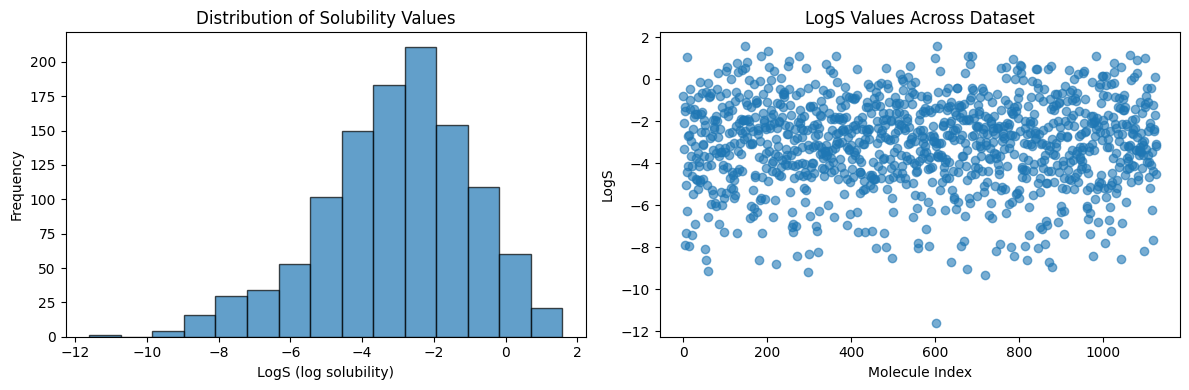

In [4]:
df = load_esol_dataset()
print(f"Dataset shape: {df.shape}")
print(f"LogS range: {df['LogS'].min():.2f} to {df['LogS'].max():.2f}")
print("\nSample data:")
print(df.head())
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(df['LogS'], bins=15, alpha=0.7, edgecolor='black')
plt.xlabel('LogS (log solubility)')
plt.ylabel('Frequency')
plt.title('Distribution of Solubility Values')
plt.subplot(1, 2, 2)
plt.scatter(range(len(df)), df['LogS'], alpha=0.6)
plt.xlabel('Molecule Index')
plt.ylabel('LogS')
plt.title('LogS Values Across Dataset')
plt.tight_layout()
plt.show()


---


## 3. Calculate Molecular Descriptors

Rather than using molecular fingerprints (high-dimensional binary vectors), we calculate a small set of **interpretable molecular descriptors** using RDKit. These descriptors capture key physicochemical properties known to influence aqueous solubility.


### 3.1 Descriptor Calculation Function

**Descriptors Calculated:**

1. **MolWt** (Molecular Weight)
   - Sum of atomic weights in the molecule
   - **Impact on Solubility**: Larger molecules generally less soluble
   - Typical drug range: 150-500 Da (Lipinski's Rule of Five)

2. **MolLogP** (Partition Coefficient)
   - Measures lipophilicity (preference for oil vs water)
   - Calculated using Wildman-Crippen method
   - **Impact on Solubility**: Higher LogP -> lower aqueous solubility
   - **Key Relationship**: LogS often inversely correlated with LogP

3. **NumHDonors** (Hydrogen Bond Donors)
   - Count of -OH and -NH groups
   - **Impact on Solubility**: More H-donors -> better water solubility
   - Important for hydrogen bonding with water molecules

4. **NumHAcceptors** (Hydrogen Bond Acceptors)
   - Count of N and O atoms capable of accepting H-bonds
   - **Impact on Solubility**: More H-acceptors -> enhanced aqueous solubility
   - Critical for forming hydration shells

5. **NumRotatableBonds**
   - Measures molecular flexibility
   - **Impact on Solubility**: Complex relationship
   - Affects conformational entropy and crystal packing

6. **TPSA** (Topological Polar Surface Area)
   - Sum of surface areas of polar atoms (O, N)
   - Units: Ų (square Angstroms)
   - **Impact on Solubility**: Higher TPSA -> better aqueous solubility
   - Also predicts membrane permeability

**Feature Engineering Note:**
These descriptors are the INPUT features (X). The LogS value is our TARGET (y) that we want to predict.

In [5]:
def calculating_molecular_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    columns = {
        "LogP": Descriptors.MolLogP(mol),
        "MolWt": Descriptors.MolWt(mol),
        "TPSA": Descriptors.TPSA(mol),
        "NumHDonors": Descriptors.NumHDonors(mol),
        "NumHAcceptors": Descriptors.NumHAcceptors(mol),
        "RotatableBonds": Descriptors.NumRotatableBonds(mol),
        "RingCount": Descriptors.RingCount(mol),
        "FractionCSP3": Descriptors.FractionCSP3(mol),
    }
    return columns
column_list = []
for smiles in df['SMILES']:
    column = calculating_molecular_descriptors(smiles)
    if column is not None:
        column_list.append(column)
columns_df = pd.DataFrame(column_list)
df = pd.concat([df, columns_df], axis=1)
print(df.head())


                                              SMILES  LogS     LogP    MolWt  \
0  OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)... -0.77 -3.10802  457.432   
1                             Cc1occc1C(=O)Nc2ccccc2 -3.30  2.84032  201.225   
2                               CC(C)=CCCC(C)=CC(=O) -2.06  2.87800  152.237   
3                 c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43 -7.87  6.29940  278.354   
4                                            c1ccsc1 -1.33  1.74810   84.143   

     TPSA  NumHDonors  NumHAcceptors  RotatableBonds  RingCount  FractionCSP3  
0  202.32           7             12               7          3      0.650000  
1   42.24           1              2               2          2      0.083333  
2   17.07           0              1               4          0      0.500000  
3    0.00           0              0               0          5      0.000000  
4    0.00           0              1               0          1      0.000000  


---


## 4. Create PyTorch Dataset Class

We implement a custom PyTorch `Dataset` class for clean, efficient data handling. While we're using scikit-learn's Decision Tree for modeling, PyTorch's Dataset provides excellent structure for:
- Consistent data access patterns
- Easy integration with DataLoaders (if needed later)
- Clean separation of data preprocessing and model training
- Extensibility to deep learning models


### 4.1 Define ESOLDataset Class

This custom Dataset:
- Stores SMILES strings and target LogS values
- Computes molecular descriptors on-the-fly or uses cached values
- Returns properly formatted feature vectors and targets

In [6]:
class ESOLDataset(Dataset):
    def __init__(self,df, split='train'):
        self.split = split
        np.random.seed(42)
        self.df = df.sample(frac=1).reset_index(drop=True)
        train_size = int(0.8 * len(self.df))
        if self.split == 'train':
            self.df = self.df.iloc[:train_size]
        else:
            self.df = self.df.iloc[train_size:]
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        logS = row['LogS']
        features = row.drop(['SMILES', 'LogS','LogP']).values.astype(np.float32)
        return {
            'features': features,
            'labels': logS
        }


### 4.2 Create Training and Test Datasets

We perform an **80-20 train-test split** to:
- Train the model on 80% of the data
- Evaluate generalization on unseen 20%
- Ensure reproducibility with fixed random state

**Important Considerations:**
- No stratification needed (regression task)
- Random splitting assumes data is representative
- Alternative: Chemical structure-based splitting for more realistic evaluation
- Test set simulates prediction on new molecules

In [7]:
train_dataset = ESOLDataset(df, split='train')
test_dataset = ESOLDataset(df, split='test')
print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")


Training samples: 902
Test samples: 226


### 4.3 Extract Feature Matrices

Convert PyTorch datasets into NumPy arrays compatible with scikit-learn.

**Feature Matrix Structure:**

**X_train / X_test:**
- Shape: (n_samples, 6 features)
- Features: [MolWt, MolLogP, NumHDonors, NumHAcceptors, NumRotatableBonds, TPSA]
- Data type: float64
- No missing values (handled during descriptor calculation)

**y_train / y_test:**
- Shape: (n_samples,)
- Values: Continuous LogS measurements
- Range: Typically -11 to +1
- Units: log₁₀(mol/L)

In [8]:
X_train = []
Y_train = []
for i in range(len(train_dataset)):
    sample = train_dataset[i]
    X_train.append(sample['features'])
    Y_train.append(sample['labels'])


---


## 5. Train Decision Tree Regression Model


### 5.1 Understanding Decision Tree Regression

**How It Works:**

Decision Trees partition the feature space into regions:

1. **Internal Nodes**: Test conditions on features
   - Example: "Is MolLogP > 2.5?"
   - "Is TPSA < 75?"

2. **Branches**: Outcomes of tests (True/False)
   - Lead to child nodes or leaf nodes

3. **Leaf Nodes**: Predictions
   - Average LogS of training samples in that region
   - Example: "Predict LogS = -3.2"

**Advantages for Molecular Data:**
- Captures non-linear relationships naturally
- No feature scaling required (tree-based splits)
- Handles feature interactions automatically
- Interpretable decision rules
- Fast training and prediction

**Potential Limitations:**
- Can overfit with deep trees
- High variance
- Not optimal for extrapolation


### 5.2 Train the Model

Fit the Decision Tree on training data:

In [9]:
clf = DecisionTreeRegressor(random_state=42)
"""
This code snippet demonstrates the usage of a DecisionTreeRegressor from the scikit-learn library.
"""
clf.fit(X_train, Y_train)
clf.get_params()


{'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'best'}

### 5.3 Prepare Test Set and Generate Predictions

Extract test features and make predictions to evaluate generalization performance.

Decision Tree Regressor Performance:
Mean Squared Error: 0.9923
R^2 Score: 0.7652
Mean Absolute Error: 0.6952


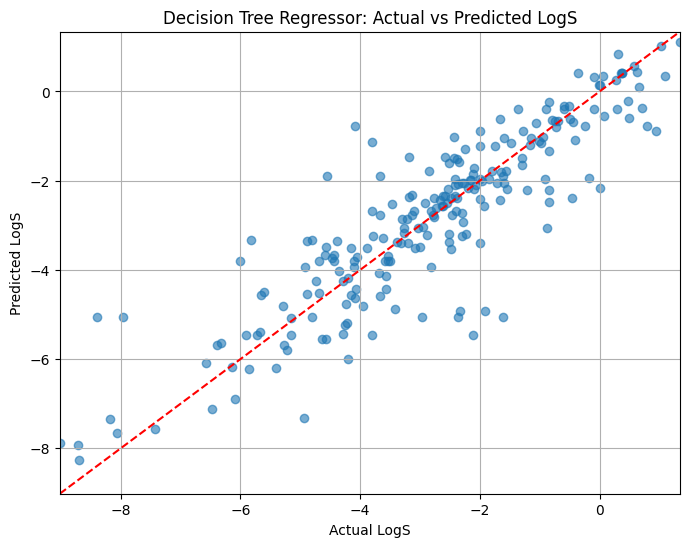

In [10]:
X_test = []
Y_test = []
for i in range(len(test_dataset)):
    sample = test_dataset[i]
    X_test.append(sample['features'])
    Y_test.append(sample['labels'])
Y_pred = clf.predict(X_test)
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)
mae = mean_absolute_error(Y_test, Y_pred)
print(f"Decision Tree Regressor Performance:")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R^2 Score: {r2:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
plt.figure(figsize=(8, 6))
plt.scatter(Y_test, Y_pred, alpha=0.6)
plt.plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], color='red', linestyle='--')
plt.xlabel('Actual LogS')
plt.ylabel('Predicted LogS')
plt.title('Decision Tree Regressor: Actual vs Predicted LogS')
plt.xlim(min(Y_test), max(Y_test))
plt.ylim(min(Y_test), max(Y_test))
plt.grid()
plt.show()


---


## 6. Model Evaluation and Performance Analysis


### 6.1 Understanding Regression Metrics

The output above displays three key regression metrics. Here's how to interpret them:


#### **R² Score (Coefficient of Determination)**

**Definition:** Proportion of variance in LogS explained by the model

**Formula:** R² = 1 - (SS_residual / SS_total)

**Interpretation:**
- **R² = 1.0**: Perfect predictions (every point on the line)


#### **MAE (Mean Absolute Error)**

**Definition:** Average absolute difference between predictions and true values

**Formula:** MAE = (1/n) × Σ|y_pred - y_true|

**Interpretation:**
- **Units**: Same as LogS (log units)
- **MAE < 0.5**: Excellent (within 0.5 log units)

**Practical Meaning:**
- MAE = 0.5 means average error of ~3× in actual solubility (10^0.5 ≈ 3.2)
- MAE = 1.0 means average error of ~10× in actual solubility
- MAE = 2.0 means average error of ~100× in actual solubility

**Advantages:**
- Easy to interpret (same units as target)
- Robust to outliers
- Treats all errors equally


#### **RMSE (Root Mean Squared Error)**

**Definition:** Square root of average squared errors

**Formula:** RMSE = √[(1/n) × Σ(y_pred - y_true)²]

**Interpretation:**
- **Units**: Same as LogS (log units)
- RMSE >> MAE suggests presence of large outlier errors
- RMSE ≈ MAE suggests consistent error distribution

**Comparison with MAE:**
- RMSE penalizes large errors more heavily (squared term)
- Use RMSE when large errors are particularly undesirable
- Use MAE for more robust evaluation


### 6.2 Interpreting Your Results

**What to Check:**

1. **Training vs Test Performance**
   ```python
   # Compare metrics
   train_r2 = clf.score(X_train, y_train)
   test_r2 = clf.score(X_test, y_test)
   
   if train_r2 - test_r2 > 0.2:
       print("Overfitting detected!")
   ```

2. **Prediction Scatter Plot**
   - Points should cluster around y=x diagonal
   - Systematic deviations indicate bias
   - Spread indicates variance

3. **Error Distribution**
   - Check residuals: `residuals = y_test - y_pred`
   - Should be roughly normally distributed
   - Patterns suggest missing features or non-linearity


### 6.3 Error Analysis

Investigate where the model struggles by visualizing the residuals. The residual plot helps identify systematic errors or biases in the model's predictions.

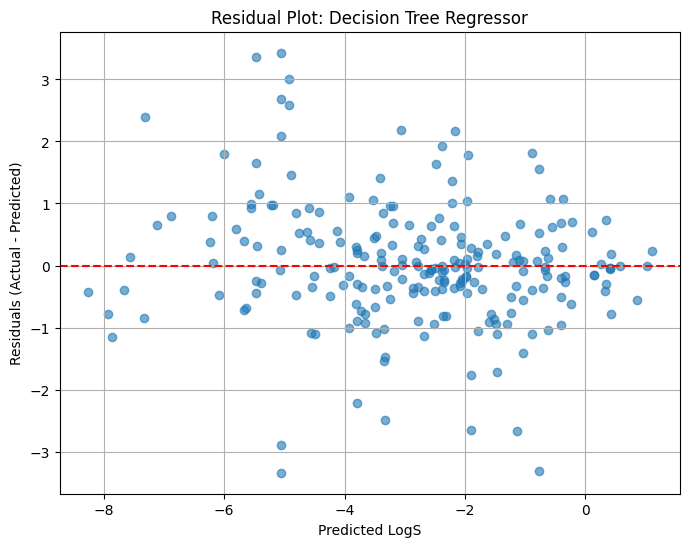

In [11]:
# Calculate residuals (Difference between actual and predicted)
residuals = np.array(Y_test) - np.array(Y_pred)

# Plot residuals
plt.figure(figsize=(8, 6))
plt.scatter(Y_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted LogS')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot: Decision Tree Regressor')
plt.grid()
plt.show()


## 7. Summary and Conclusions


### 7.1 Key Insights

**About Solubility Prediction:**
- Simple descriptors (MolWt, LogP, TPSA) capture major solubility trends
- No complex fingerprints needed for baseline performance
- LogP (lipophilicity) typically dominant feature
- Aqueous solubility is challenging: many factors beyond structure

**About Decision Trees:**
- Fast and interpretable
- Handle non-linear relationships naturally
- Can overfit without proper regularization
- Ensemble methods (Random Forest) often better

---

## Exercise: Decision Tree Classification

In this exercise, you will adapt the pipeline above to perform **Classification** instead of Regression. 
Instead of predicting the continuous `LogS` value, you will predict whether a molecule is highly soluble or poorly soluble.

**Task Description:**
1. **Define a Solubility Threshold:** Convert the continuous `LogS` values into binary labels (e.g., `0` for low solubility, `1` for high solubility) using a cutoff of `-2.0`.
2. **Split Data:** Split the dataset into training and test sets using `train_test_split`.
3. **Train a Classifier:** Initialize and train a `DecisionTreeClassifier` from `sklearn.tree`.
4. **Evaluate:** Predict on the test set, calculate the accuracy, and print the classification report.

In [12]:
# Import required libraries for classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
import numpy as np

def perform_classification(df):
    """
    Task: Train and evaluate a Decision Tree Classifier.
    
    Steps:
    1. Create a binary target column 'SolubilityClass'.
    2. Split the data.
    3. Train the classifier.
    4. Print the evaluation metrics.
    """
    # 1. Create binary labels (Threshold = -2.0)
    # If LogS < -2.0, class is 0 (poorly soluble), else 1 (soluble)
    # df['SolubilityClass'] = ...
    # YOUR CODE HERE
    
    # 2. Split the data (assuming you have features X)
    # X = df[['your_features_here']]
    # y = df['SolubilityClass']
    # X_train, X_test, y_train, y_test = train_test_split(...)
    # YOUR CODE HERE
    
    # 3. Train the model
    # clf = DecisionTreeClassifier(random_state=42)
    # clf.fit(...)
    # YOUR CODE HERE
    
    # 4. Evaluate the model
    # y_pred = clf.predict(X_test)
    # print(classification_report(y_test, y_pred))
    # YOUR CODE HERE
    
    pass

# Uncomment the line below to test your code:
# perform_classification(df)  # Assuming df is available from earlier cells


### Bonus Exercise: Random Forest Classifier

Try training a `RandomForestClassifier` and compare its performance to the Decision Tree. You can also use `GridSearchCV` to find the best hyperparameters.

In [13]:
from sklearn.ensemble import RandomForestClassifier

def train_random_forest(X_train, y_train, X_test, y_test):
    # rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
    # YOUR CODE HERE
    pass
